<a href="https://colab.research.google.com/github/drm69/PCVK25_3F_12/blob/main/Kuis2_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

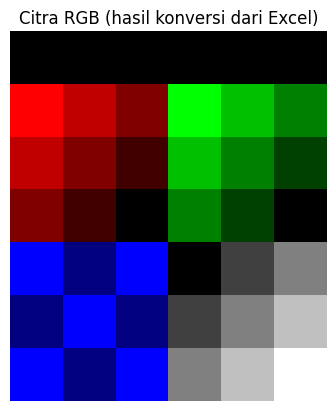


=== GRAYSCALE IMAGE ===
[[  0   0   0   0   0   0]
 [ 76  57  38 149 112  75]
 [ 57  38  19 112  75  37]
 [ 38  19   0  75  37   0]
 [ 29  14  29   0  63 127]
 [ 14  29  14  63 127 191]
 [ 29  14  29 127 191 254]]


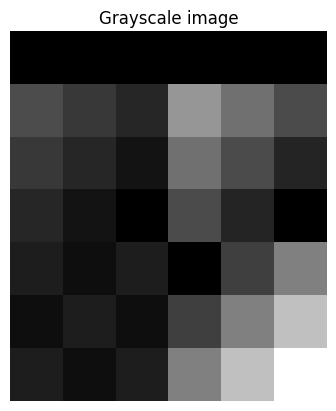


=== NORMALIZED GRAYSCALE (0–1) ===
[[0.         0.         0.         0.         0.         0.        ]
 [0.29803922 0.22352941 0.14901961 0.58431373 0.43921569 0.29411765]
 [0.22352941 0.14901961 0.0745098  0.43921569 0.29411765 0.14509804]
 [0.14901961 0.0745098  0.         0.29411765 0.14509804 0.        ]
 [0.11372549 0.05490196 0.11372549 0.         0.24705882 0.49803922]
 [0.05490196 0.11372549 0.05490196 0.24705882 0.49803922 0.74901961]
 [0.11372549 0.05490196 0.11372549 0.49803922 0.74901961 0.99607843]]

=== PANJANG VEKTOR HOG ===
81
=== TABEL FITUR HOG ===
    Indeks  Nilai_Fitur_HOG
0        0         0.000000
1        1         0.000000
2        2         0.000000
3        3         0.000000
4        4         0.707107
..     ...              ...
76      76         0.577350
77      77         0.000000
78      78         0.000000
79      79         0.000000
80      80         0.000000

[81 rows x 2 columns]

=== ANALISIS FITUR ===
Jumlah fitur      : 81
Fitur maksimum    :

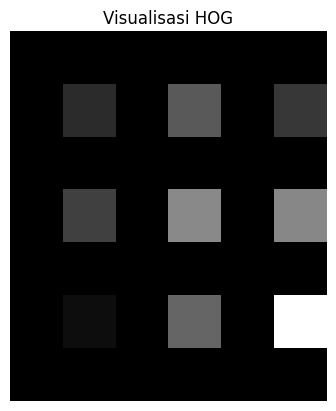

In [ ]:
import pandas as pd
import numpy as np
from skimage.feature import hog
from skimage import color

# ============================================
# 1. LOAD EXCEL DAN KONVERSI KE CITRA RGB
# ============================================

file_path = "/content/citra kuis 2.xlsx"
df = pd.read_excel(file_path, header=None)

def parse_rgb(cell):
    parts = [p.strip() for p in str(cell).split(',')]
    parts = [p for p in parts if p != ""]
    if len(parts) != 3:
        return [0, 0, 0]
    return [int(parts[0]), int(parts[1]), int(parts[2])]

h, w = df.shape
img = np.zeros((h, w, 3), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        img[i, j] = parse_rgb(df.iloc[i, j])

plt.imshow(img)
plt.title("Citra RGB (hasil konversi dari Excel)")
plt.axis('off')
plt.show()

# ============================================
# 2. KONVERSI KE GRAYSCALE
# ============================================

gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

print("\n=== GRAYSCALE IMAGE ===")
print(gray)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale image")
plt.axis('off')
plt.show()

# ============================================
# 3. NORMALISASI KE RENTANG 0–1
# ============================================

gray_norm = gray / 255.0

print("\n=== NORMALIZED GRAYSCALE (0–1) ===")
print(gray_norm)

# ============================================
# 4. EKSTRAKSI FITUR HOG
# ============================================

features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(2, 2),
    cells_per_block=(1, 1),
    visualize=True,
    feature_vector=True
)

print("\n=== PANJANG VEKTOR HOG ===")
print(len(features))

print("=== TABEL FITUR HOG ===")
print(df_features)

# Jika ingin simpan ke file:
df_features.to_excel("fitur_hog_output.xlsx", index=False)

# =====================================================
# 5. ANALISIS SEDERHANA
# =====================================================
print("\n=== ANALISIS FITUR ===")
print(f"Jumlah fitur      : {len(features)}")
print(f"Fitur maksimum    : {features.max():.4f}")
print(f"Fitur minimum     : {features.min():.4f}")
print(f"Rata-rata fitur   : {features.mean():.4f}")

print("\nInterpretasi:")
print("- Nilai tinggi biasanya muncul pada area yang memiliki tepi kuat.")
print("- Nilai rendah menunjukkan area yang lebih homogen (flat).")
print("- Distribusi fitur HOG menunjukkan karakteristik bentuk citra.")

plt.imshow(hog_image, cmap='gray')
plt.title("Visualisasi HOG")
plt.axis('off')
plt.show()